# Bike Details Dataset – Complete Analysis

This notebook answers all 10 questions using Python, Pandas, Matplotlib, and Seaborn.

## Question 1: Load Dataset and Inspect

In [11]:
import pandas as pd
import seaborn as sns
df = pd.read_csv("BIKE DETAILS.csv")
df.head(10), df.shape, df.columns

(                                   name  selling_price  year seller_type  \
 0             Royal Enfield Classic 350         175000  2019  Individual   
 1                             Honda Dio          45000  2017  Individual   
 2   Royal Enfield Classic Gunmetal Grey         150000  2018  Individual   
 3     Yamaha Fazer FI V 2.0 [2016-2018]          65000  2015  Individual   
 4                 Yamaha SZ [2013-2014]          20000  2011  Individual   
 5                      Honda CB Twister          18000  2010  Individual   
 6                  Honda CB Hornet 160R          78500  2018  Individual   
 7  Royal Enfield Bullet 350 [2007-2011]         180000  2008  Individual   
 8                Hero Honda CBZ extreme          30000  2010  Individual   
 9                    Bajaj Discover 125          50000  2016  Individual   
 
        owner  km_driven  ex_showroom_price  
 0  1st owner        350                NaN  
 1  1st owner       5650                NaN  
 2  1st owner

## Question 2: Missing Values

In [2]:
df.isnull().sum()

name                   0
selling_price          0
year                   0
seller_type            0
owner                  0
km_driven              0
ex_showroom_price    435
dtype: int64

## Question 3: Selling Price Distribution

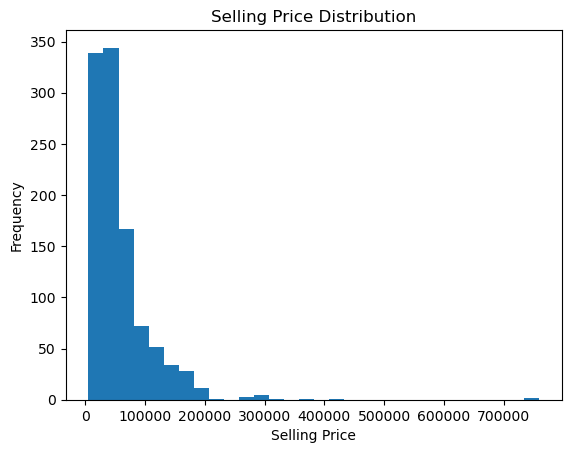

In [3]:
import matplotlib.pyplot as plt
plt.hist(df['selling_price'], bins=30)
plt.xlabel('Selling Price')
plt.ylabel('Frequency')
plt.title('Selling Price Distribution')
plt.show()

## Question 4: Avg Selling Price by Seller Type

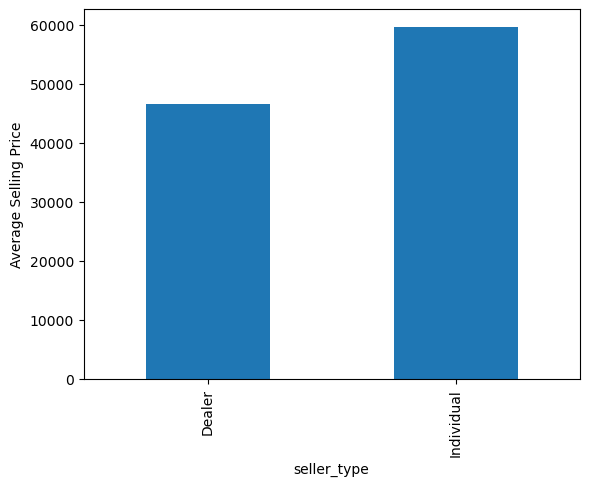

In [4]:
df.groupby('seller_type')['selling_price'].mean().plot(kind='bar')
plt.ylabel('Average Selling Price')
plt.show()

## Question 5: Avg KM Driven by Owner

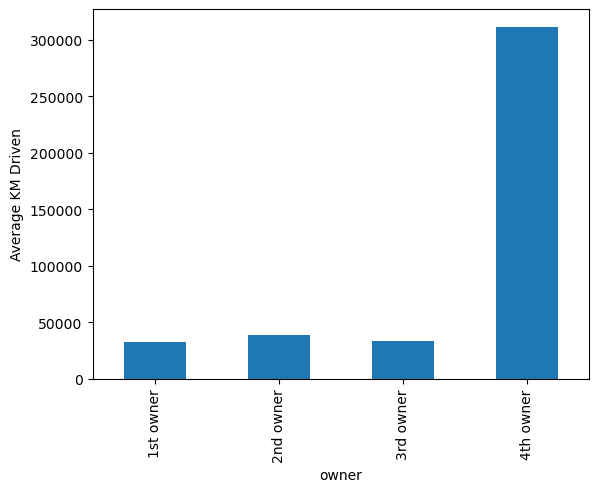

In [5]:
df.groupby('owner')['km_driven'].mean().plot(kind='bar')
plt.ylabel('Average KM Driven')
plt.show()

## Question 6: Outlier Removal using IQR

In [6]:
Q1 = df['km_driven'].quantile(0.25)
Q3 = df['km_driven'].quantile(0.75)
IQR = Q3 - Q1

df_clean = df[(df['km_driven'] >= Q1 - 1.5*IQR) & (df['km_driven'] <= Q3 + 1.5*IQR)]
df['km_driven'].describe(), df_clean['km_driven'].describe()

(count      1061.000000
 mean      34359.833176
 std       51623.152702
 min         350.000000
 25%       13500.000000
 50%       25000.000000
 75%       43000.000000
 max      880000.000000
 Name: km_driven, dtype: float64,
 count     1022.000000
 mean     28203.415851
 std      19552.083583
 min        350.000000
 25%      13000.000000
 50%      24000.000000
 75%      40000.000000
 max      86000.000000
 Name: km_driven, dtype: float64)

## Question 7: Year vs Selling Price

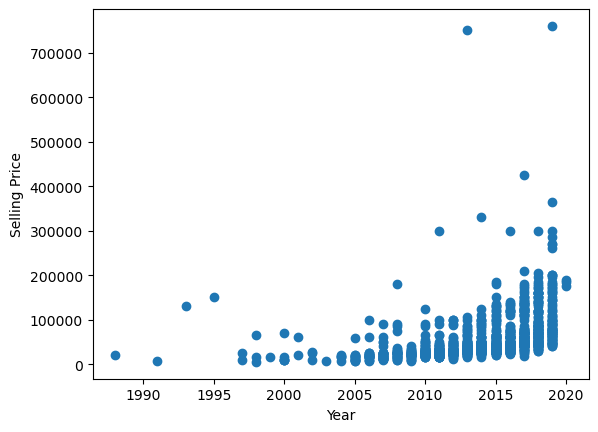

In [7]:
plt.scatter(df['year'], df['selling_price'])
plt.xlabel('Year')
plt.ylabel('Selling Price')
plt.show()

## Question 8: One-Hot Encoding Seller Type

In [8]:
df_encoded = pd.get_dummies(df, columns=['seller_type'])
df_encoded.head()

,name,selling_price,year,owner,km_driven,ex_showroom_price,seller_type_Dealer,seller_type_Individual
0,Royal Enfield Classic 350,175000,2019,1st owner,350,NaN,False,True
1,Honda Dio,45000,2017,1st owner,5650,NaN,False,True
2,Royal Enfield Classic Gunmetal Grey,150000,2018,1st owner,12000,148114.0,False,True
3,Yamaha Fazer FI V 2.0 [2016-2018],65000,2015,1st owner,23000,89643.0,False,True
4,Yamaha SZ [2013-2014],20000,2011,2nd owner,21000,NaN,False,True


## Question 9: Correlation Heatmap

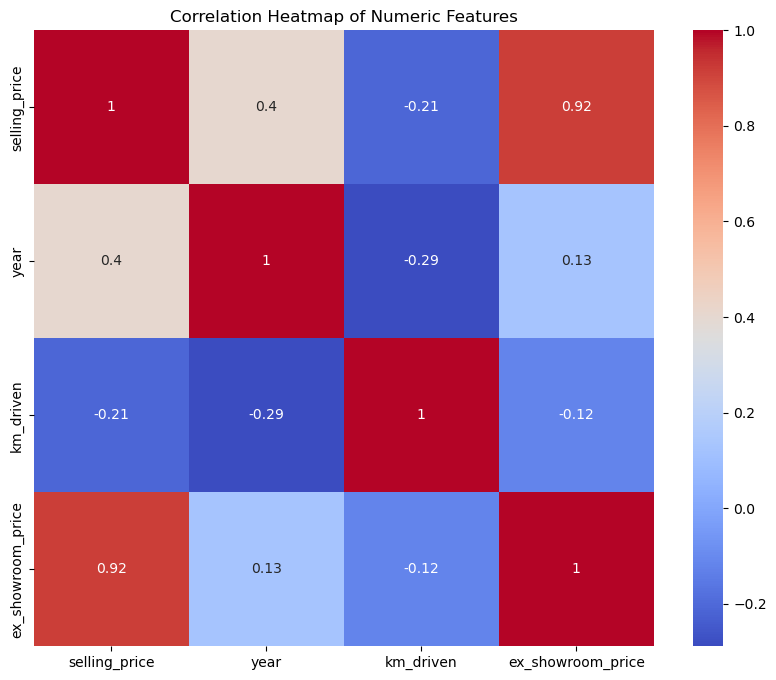

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numeric columns
numeric_df = df_encoded.select_dtypes(include=['int64', 'float64'])

# Correlation matrix
corr_matrix = numeric_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=True)
plt.title("Correlation Heatmap of Numeric Features")
plt.show()


## Question 10: Summary Report

**Key Factors Affecting Selling Price:**
- Bike year (newer bikes cost more)
- KM driven (lower usage → higher price)
- Seller type and ownership

**Data Cleaning & Feature Engineering:**
- Checked missing values
- Removed outliers using IQR
- One-hot encoded categorical variables
